# TensorWave Break-Even Calculator & Customer Retention Map

**When does switching from an Nvidia provider to TensorWave pay for itself?**  
_Noah Assefa · Ed W. Clark High School · Las Vegas, NV · May 2026_

---

## Why this matters for TensorWave

TensorWave's pricing edge is largest *today*, while Nvidia capacity is supply-constrained. The strategic question is **retention**: when H100 supply normalizes and Nvidia prices soften, which customers have already recouped their migration cost (and will stay), and which are still underwater (and may churn back)?

This notebook (1) models the break-even point for a switch, (2) maps every customer segment onto a churn-risk quadrant, and (3) produces a scored retention table the founders can act on.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---- Presentation theme: clean white background, consistent palette ----
PALETTE = {
    "tensorwave": "#E8472A",   # accent: red-orange, reserved for TensorWave
    "tw_dark":    "#B5331C",
    "coreweave":  "#1D3557",   # deep navy
    "lambda":     "#457B9D",   # steel blue
    "runpod":     "#8FB8CE",   # light blue
    "ink":        "#1A1A1A",   # near-black text
    "muted":      "#6B7280",   # grey captions
    "grid":       "#E5E7EB",
}

def apply_theme():
    mpl.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.titlecolor": PALETTE["ink"],
        "axes.labelsize": 11,
        "axes.labelcolor": PALETTE["ink"],
        "axes.edgecolor": PALETTE["grid"],
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": PALETTE["grid"],
        "grid.linewidth": 0.8,
        "xtick.color": PALETTE["muted"],
        "ytick.color": PALETTE["muted"],
        "text.color": PALETTE["ink"],
        "legend.frameon": False,
        "figure.dpi": 110,
    })

def style_axes(ax, grid_axis="y"):
    """Strip chartjunk: hide top/right spines, keep light grid on one axis."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(PALETTE["grid"])
    ax.grid(True, axis=grid_axis, alpha=0.9)
    ax.grid(False, axis=("x" if grid_axis == "y" else "y"))

def footnote(fig, text):
    fig.text(0.01, -0.02, text, ha="left", va="top",
             fontsize=8, color=PALETTE["muted"], style="italic")

apply_theme()

## 1. Assumptions & methodology *(read this first — it's what makes the numbers defensible)*

**Model memory.** Weights only, FP16 = `params × 2 bytes`. E.g. 70B → 140 GB. This is a transparent *floor*; real deployments add KV-cache and activations, which would only **increase** the number of Nvidia GPUs required and therefore **strengthen** TensorWave's case. We stay conservative.

**GPUs needed** = `ceil(memory_needed / vram_per_gpu)`, minimum 1. Capacity-based packing.

**Monthly cost** = `gpus_needed × price_per_hour × hours`, where `hours` = **wall-clock hours the workload runs per month per GPU** (720 = 24x7). It is *not* a pre-aggregated GPU-hour total — we multiply by GPU count exactly once, so there is no double-counting.

**Break-even (months)** = `migration_cost / monthly_savings`. Migration cost = engineer-hours to port off CUDA × \$150/hr. Returns `None` when TensorWave is not cheaper (no payback).

**Known limitation — step behavior.** Savings jump only when the competitor needs an *extra* GPU but TensorWave does not. So 7B / 13B / 30B models (all fit on one GPU either way) share identical savings; the advantage appears at **70B+**. We surface this rather than hide it.

In [2]:
# --- Inputs (public data + standard industry rates) ---

# Model size -> memory footprint (FP16 weights, 2 bytes/param)
model_memory = {
    "7B parameters":    14,
    "13B parameters":   26,
    "30B parameters":   60,
    "70B parameters":  140,
    "100B+ parameters": 200,
}

# Provider on-demand pricing and on-board VRAM
provider_pricing = {
    "CoreWeave H100 HGX":    {"price_per_hour": 6.16, "vram_gb": 80},
    "Lambda Labs H100 SXM5": {"price_per_hour": 4.09, "vram_gb": 80},
    "RunPod H100 SXM5":      {"price_per_hour": 2.69, "vram_gb": 80},
    "TensorWave MI300X":     {"price_per_hour": 1.71, "vram_gb": 192},
}

# One-time ROCm migration effort (engineer-hours) by CUDA entanglement
migration_costs = {
    "Minimal CUDA dependency":  20,
    "Moderate CUDA dependency": 80,
    "Heavy CUDA dependency":   200,
}

ENGINEER_HOURLY_RATE = 150  # USD, standard ML engineer blended rate

print("Loaded:", list(provider_pricing), "|", list(model_memory))


Loaded: ['CoreWeave H100 HGX', 'Lambda Labs H100 SXM5', 'RunPod H100 SXM5', 'TensorWave MI300X'] | ['7B parameters', '13B parameters', '30B parameters', '70B parameters', '100B+ parameters']


In [3]:
def calculate_breakeven(model_size, current_provider, gpu_hours_per_month,
                        migration_level, engineer_rate=ENGINEER_HOURLY_RATE):
    """Return the economics of moving one workload to TensorWave MI300X.

    gpu_hours_per_month = wall-clock hours the workload runs per month (per GPU).
    """
    memory_needed = model_memory[model_size]
    current    = provider_pricing[current_provider]
    tensorwave = provider_pricing["TensorWave MI300X"]

    # Capacity-based packing: ceil division, at least one GPU
    gpus_current    = max(1, int(np.ceil(memory_needed / current["vram_gb"])))
    gpus_tensorwave = max(1, int(np.ceil(memory_needed / tensorwave["vram_gb"])))

    current_monthly    = gpus_current    * current["price_per_hour"]    * gpu_hours_per_month
    tensorwave_monthly = gpus_tensorwave * tensorwave["price_per_hour"] * gpu_hours_per_month
    monthly_savings    = current_monthly - tensorwave_monthly

    migration_cost = migration_costs[migration_level] * engineer_rate

    # Break-even only defined when there is a positive monthly saving
    breakeven_months = (migration_cost / monthly_savings) if monthly_savings > 0 else None

    return {
        "current_monthly": current_monthly,
        "tensorwave_monthly": tensorwave_monthly,
        "monthly_savings": monthly_savings,
        "annual_savings": monthly_savings * 12,
        "migration_cost": migration_cost,
        "breakeven_months": breakeven_months,
        "gpus_needed_current": gpus_current,
        "gpus_needed_tensorwave": gpus_tensorwave,
        "memory_needed": memory_needed,
    }


# --- Worked example: 70B model, leaving CoreWeave, 500 hrs/mo, moderate port ---
r = calculate_breakeven("70B parameters", "CoreWeave H100 HGX", 500, "Moderate CUDA dependency")
print("=== BREAK-EVEN ANALYSIS — 70B on CoreWeave -> TensorWave ===")
print(f"Memory required          : {r['memory_needed']} GB (FP16 weights)")
print(f"GPUs on CoreWeave        : {r['gpus_needed_current']} x H100 80GB")
print(f"GPUs on TensorWave       : {r['gpus_needed_tensorwave']} x MI300X 192GB")
print(f"Monthly cost  CoreWeave  : ${r['current_monthly']:,.2f}")
print(f"Monthly cost  TensorWave : ${r['tensorwave_monthly']:,.2f}")
print(f"Monthly savings          : ${r['monthly_savings']:,.2f}")
print(f"Annual savings           : ${r['annual_savings']:,.2f}")
print(f"Migration cost (one-time): ${r['migration_cost']:,.2f}")
print(f"Break-even               : {r['breakeven_months']:.1f} months")


=== BREAK-EVEN ANALYSIS — 70B on CoreWeave -> TensorWave ===
Memory required          : 140 GB (FP16 weights)
GPUs on CoreWeave        : 2 x H100 80GB
GPUs on TensorWave       : 1 x MI300X 192GB
Monthly cost  CoreWeave  : $6,160.00
Monthly cost  TensorWave : $855.00
Monthly savings          : $5,305.00
Annual savings           : $63,660.00
Migration cost (one-time): $12,000.00
Break-even               : 2.3 months


## 2. Scenario grid

Sweep every model size against a range of monthly usage levels (leaving CoreWeave, moderate migration). This is the raw material for both the ROI charts and the retention table.

In [4]:
USAGE_LEVELS = [100, 300, 500, 1000]   # wall-clock hours/month
BASELINE_PROVIDER = "CoreWeave H100 HGX"
MIGRATION = "Moderate CUDA dependency"

rows = []
for model in model_memory:
    for hours in USAGE_LEVELS:
        x = calculate_breakeven(model, BASELINE_PROVIDER, hours, MIGRATION)
        rows.append({
            "Model": model,
            "Memory (GB)": x["memory_needed"],
            "GPU Hours/Month": hours,
            "Monthly Savings": x["monthly_savings"],
            "Annual Savings": x["annual_savings"],
            "Breakeven Months": x["breakeven_months"],
            "GPUs CoreWeave": x["gpus_needed_current"],
            "GPUs TensorWave": x["gpus_needed_tensorwave"],
        })

df_scenarios = pd.DataFrame(rows)
df_scenarios


,Model,Memory (GB),GPU Hours/Month,Monthly Savings,Annual Savings,Breakeven Months,GPUs CoreWeave,GPUs TensorWave
0,7B parameters,14,100,445.0,5340.0,26.966292,1,1
1,7B parameters,14,300,1335.0,16020.0,8.988764,1,1
2,7B parameters,14,500,2225.0,26700.0,5.393258,1,1
3,7B parameters,14,1000,4450.0,53400.0,2.696629,1,1
4,13B parameters,26,100,445.0,5340.0,26.966292,1,1
5,13B parameters,26,300,1335.0,16020.0,8.988764,1,1
6,13B parameters,26,500,2225.0,26700.0,5.393258,1,1
7,13B parameters,26,1000,4450.0,53400.0,2.696629,1,1
8,30B parameters,60,100,445.0,5340.0,26.966292,1,1
9,30B parameters,60,300,1335.0,16020.0,8.988764,1,1


## 3. ROI charts

Left: annual savings scale with usage and model size. Right: months to break even, with the **3-month (sticky)** and **6-month (watch)** bands marked. A larger model crosses into profitability faster because CoreWeave needs extra GPUs that TensorWave does not.

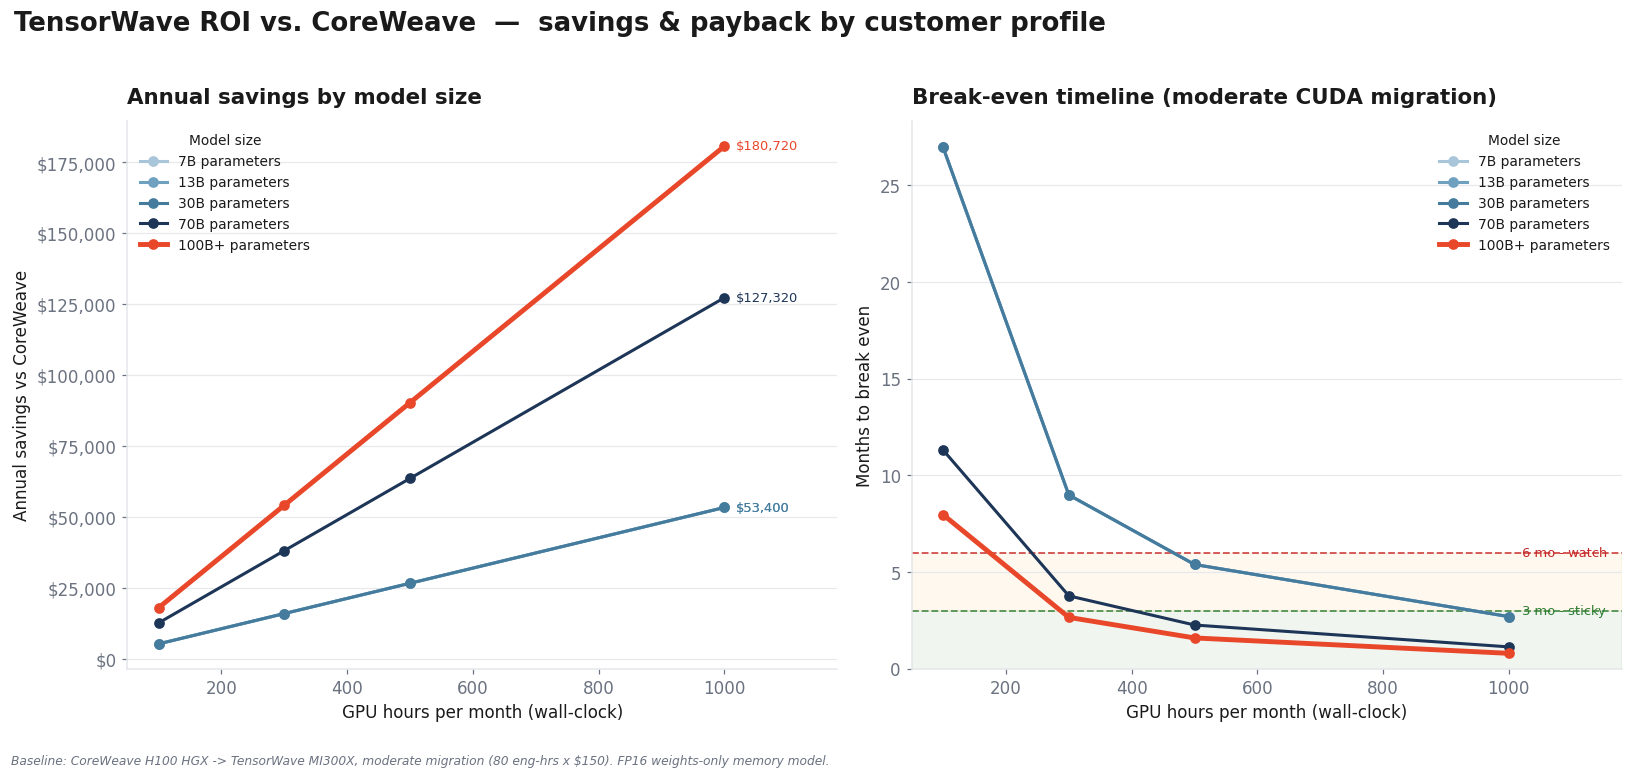

In [5]:
os.makedirs("visualizations", exist_ok=True)

# Sequential model-size shading; TensorWave accent reserved for the largest/critical line
model_list = list(model_memory)
line_colors = {
    "7B parameters":    "#A8C5DA",
    "13B parameters":   "#6FA0C0",
    "30B parameters":   "#457B9D",
    "70B parameters":   "#1D3557",
    "100B+ parameters": PALETTE["tensorwave"],   # accent = biggest payoff
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# ---- Panel 1: annual savings ----
for model in model_list:
    s = df_scenarios[df_scenarios["Model"] == model]
    lw = 3.2 if model == "100B+ parameters" else 2.0
    axes[0].plot(s["GPU Hours/Month"], s["Annual Savings"], marker="o", ms=6,
                 color=line_colors[model], linewidth=lw, label=model, zorder=3)
    last = s.iloc[-1]
    axes[0].text(last["GPU Hours/Month"] + 18, last["Annual Savings"],
                 f"${last['Annual Savings']:,.0f}", va="center", fontsize=8.5,
                 color=line_colors[model])
axes[0].set_xlabel("GPU hours per month (wall-clock)")
axes[0].set_ylabel("Annual savings vs CoreWeave")
axes[0].set_title("Annual savings by model size", loc="left", pad=12)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f"${v:,.0f}"))
axes[0].set_xlim(50, 1180)
axes[0].legend(title="Model size", fontsize=9, title_fontsize=9, loc="upper left")
style_axes(axes[0], grid_axis="y")

# ---- Panel 2: break-even timeline ----
axes[1].axhspan(0, 3, color="#2E7D32", alpha=0.07, zorder=0)
axes[1].axhspan(3, 6, color="#F9A825", alpha=0.07, zorder=0)
for model in model_list:
    s = df_scenarios[df_scenarios["Model"] == model].dropna(subset=["Breakeven Months"])
    lw = 3.2 if model == "100B+ parameters" else 2.0
    axes[1].plot(s["GPU Hours/Month"], s["Breakeven Months"], marker="o", ms=6,
                 color=line_colors[model], linewidth=lw, label=model, zorder=3)
axes[1].axhline(3, color="#2E7D32", ls="--", lw=1.2, alpha=0.8)
axes[1].axhline(6, color="#C62828", ls="--", lw=1.2, alpha=0.8)
axes[1].text(1015, 3, " 3 mo - sticky", color="#2E7D32", fontsize=8.5, va="center")
axes[1].text(1015, 6, " 6 mo - watch", color="#C62828", fontsize=8.5, va="center")
axes[1].set_xlabel("GPU hours per month (wall-clock)")
axes[1].set_ylabel("Months to break even")
axes[1].set_title("Break-even timeline (moderate CUDA migration)", loc="left", pad=12)
axes[1].set_xlim(50, 1180)
axes[1].set_ylim(0, max(28, df_scenarios["Breakeven Months"].max() * 1.05))
axes[1].legend(title="Model size", fontsize=9, title_fontsize=9, loc="upper right")
style_axes(axes[1], grid_axis="y")

fig.suptitle("TensorWave ROI vs. CoreWeave  —  savings & payback by customer profile",
             fontsize=17, fontweight="bold", x=0.012, ha="left", y=1.02)
footnote(fig, "Baseline: CoreWeave H100 HGX -> TensorWave MI300X, moderate migration "
              "(80 eng-hrs x $150). FP16 weights-only memory model.")
plt.tight_layout()
plt.savefig("visualizations/breakeven_analysis.png", dpi=200, bbox_inches="tight")
plt.show()


## 4. Customer segmentation quadrant — *the retention map*

Each dot is a customer profile: **model size (y)** against **monthly usage (x)**, colored by break-even time (green = fast payback = sticky, red = slow payback = churn-prone). Median split lines carve the field into four quadrants.

**The strategic read:** customers in the upper-right (large models, heavy usage) recoup migration cost in weeks and are effectively locked in. Customers in the lower-left (small models, light usage) take the longest to break even — they are the ones most likely to defect once Nvidia supply, and pricing, normalize. That lower-left cell is exactly where TensorWave should focus migration credits, support, or contract incentives.

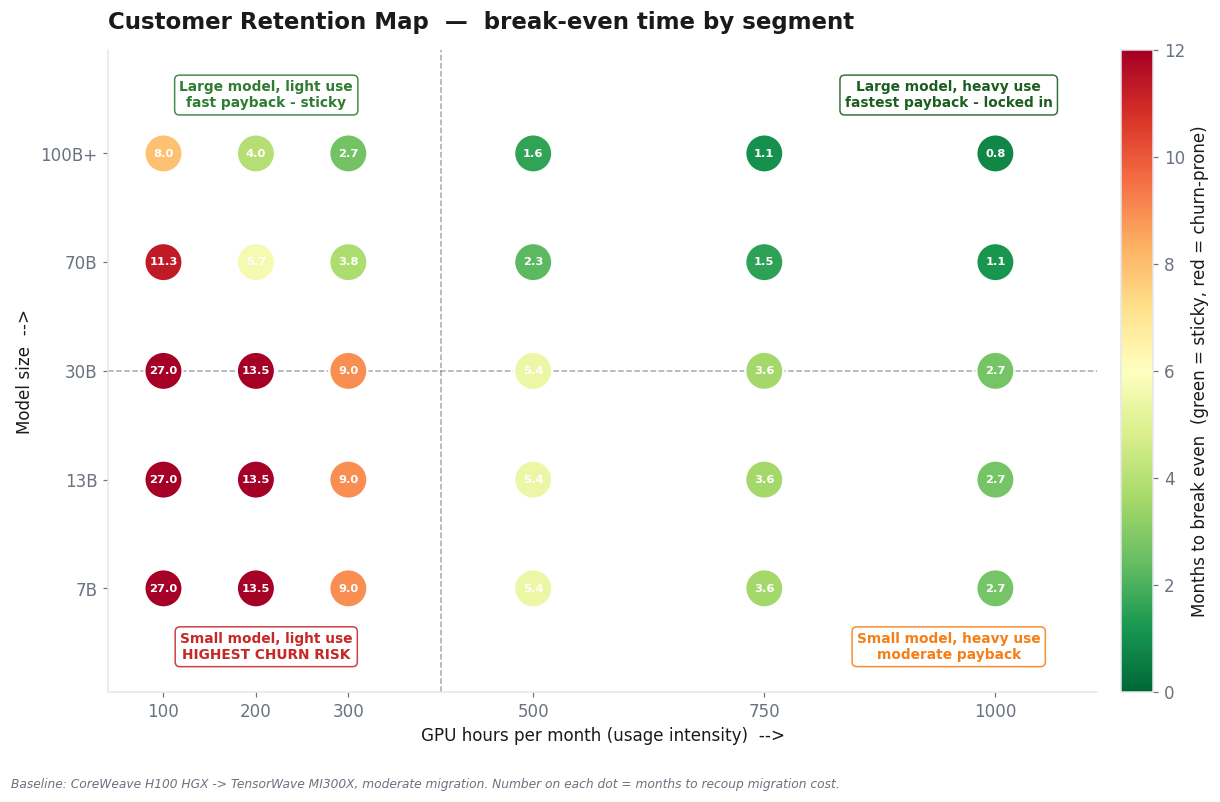

In [6]:
# Build a denser grid for the quadrant so the gradient is readable
quad_hours  = [100, 200, 300, 500, 750, 1000]
quad_models = list(model_memory)

qx, qy, qc, qmem = [], [], [], []
for mi, model in enumerate(quad_models):
    for hours in quad_hours:
        x = calculate_breakeven(model, BASELINE_PROVIDER, hours, MIGRATION)
        be = x["breakeven_months"]
        qx.append(hours)
        qy.append(mi)                       # categorical model axis
        qc.append(be if be is not None else np.nan)
        qmem.append(x["memory_needed"])

qc = np.array(qc, dtype=float)

fig, ax = plt.subplots(figsize=(12, 7))

# Quadrant split lines (medians of the plotted ranges)
x_split = np.median(quad_hours)
y_split = (len(quad_models) - 1) / 2
ax.axvline(x_split, color=PALETTE["muted"], ls="--", lw=1, alpha=0.6, zorder=1)
ax.axhline(y_split, color=PALETTE["muted"], ls="--", lw=1, alpha=0.6, zorder=1)

# Scatter colored by break-even (reversed RdYlGn: high months = red = at risk)
sc = ax.scatter(qx, qy, c=qc, cmap="RdYlGn_r", s=620, edgecolor="white",
                linewidth=1.4, vmin=0, vmax=12, zorder=3)

# Annotate each point with its break-even in months
for x, y, be in zip(qx, qy, qc):
    label = f"{be:.1f}" if np.isfinite(be) else "n/a"
    ax.annotate(label, (x, y), ha="center", va="center", fontsize=7.5,
                color="white", fontweight="bold", zorder=4)

ax.set_yticks(range(len(quad_models)))
ax.set_yticklabels([m.replace(" parameters", "") for m in quad_models])
ax.set_xticks(quad_hours)
ax.set_xlabel("GPU hours per month (usage intensity)  -->")
ax.set_ylabel("Model size  -->")
ax.set_title("Customer Retention Map  —  break-even time by segment",
             loc="left", pad=14, fontsize=15)
ax.set_xlim(40, 1110)
ax.set_ylim(-0.95, len(quad_models) - 0.05)

# Quadrant captions, boxed so they stay legible over the data points
cap = dict(fontsize=9, fontweight="bold", zorder=6, ha="center", va="center")
def boxed(x, y, text, color):
    ax.text(x, y, text, transform=ax.transAxes, color=color,
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec=color,
                      alpha=0.88, lw=1.0), **cap)
boxed(0.16, 0.93, "Large model, light use\nfast payback - sticky", "#2E7D32")
boxed(0.85, 0.93, "Large model, heavy use\nfastest payback - locked in", "#1B5E20")
boxed(0.16, 0.07, "Small model, light use\nHIGHEST CHURN RISK", "#C62828")
boxed(0.85, 0.07, "Small model, heavy use\nmoderate payback", "#F57F17")

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Months to break even  (green = sticky, red = churn-prone)")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(False)
footnote(fig, "Baseline: CoreWeave H100 HGX -> TensorWave MI300X, moderate migration. "
              "Number on each dot = months to recoup migration cost.")
plt.tight_layout()
plt.savefig("visualizations/retention_quadrant.png", dpi=200, bbox_inches="tight")
plt.show()


## 5. Customer risk scoring table

Every segment (model size x usage level) scored on monthly savings, break-even time, and a churn-risk label. The label is purely a function of payback speed:

| Break-even | Churn risk | Rationale |
|---|---|---|
| ≤ 3 months | **Low** | Cost recovered before Nvidia supply can normalize — sticky |
| 3–6 months | **Medium** | Recovers within a typical planning cycle — monitor |
| > 6 months or none | **High** | Long/!no payback — first to defect when H100 prices fall |

This is the founders' prioritized retention worklist.

In [7]:
def churn_risk(breakeven_months):
    """Churn label from payback speed. None = never breaks even = High."""
    if breakeven_months is None:
        return "High"
    if breakeven_months <= 3:
        return "Low"
    if breakeven_months <= 6:
        return "Medium"
    return "High"

risk = df_scenarios.copy()
risk["Churn Risk"] = risk["Breakeven Months"].apply(churn_risk)

risk_table = risk[[
    "Model", "GPU Hours/Month", "Monthly Savings", "Annual Savings",
    "Breakeven Months", "Churn Risk",
]].copy()

# Sort worst-first so the retention worklist reads top-down
risk_order = {"High": 0, "Medium": 1, "Low": 2}
risk_table = risk_table.sort_values(
    by=["Churn Risk", "Breakeven Months"],
    key=lambda col: col.map(risk_order) if col.name == "Churn Risk" else col,
    ascending=[True, False],
).reset_index(drop=True)

RISK_BG = {"High": "#F8D7DA", "Medium": "#FFF3CD", "Low": "#D4EDDA"}
RISK_FG = {"High": "#842029", "Medium": "#664D03", "Low": "#0F5132"}

def color_risk(val):
    return f"background-color: {RISK_BG[val]}; color: {RISK_FG[val]}; font-weight: 700;"

styled = (
    risk_table.style
    .format({
        "Monthly Savings": "${:,.0f}",
        "Annual Savings": "${:,.0f}",
        "Breakeven Months": lambda v: "no payback" if pd.isna(v) else f"{v:.1f}",
    })
    .map(color_risk, subset=["Churn Risk"])
    .set_caption("TensorWave Customer Retention Worklist (worst-first)")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"),
                                          ("font-weight", "bold"),
                                          ("padding", "8px"),
                                          ("color", "#1A1A1A")]},
        {"selector": "th", "props": [("background-color", "#1D3557"),
                                     ("color", "white"),
                                     ("text-align", "left")]},
    ])
    .hide(axis="index")
)
styled


Model,GPU Hours/Month,Monthly Savings,Annual Savings,Breakeven Months,Churn Risk
7B parameters,100,$445,"$5,340",27.0,High
13B parameters,100,$445,"$5,340",27.0,High
30B parameters,100,$445,"$5,340",27.0,High
70B parameters,100,"$1,061","$12,732",11.3,High
7B parameters,300,"$1,335","$16,020",9.0,High
13B parameters,300,"$1,335","$16,020",9.0,High
30B parameters,300,"$1,335","$16,020",9.0,High
100B+ parameters,100,"$1,506","$18,072",8.0,High
7B parameters,500,"$2,225","$26,700",5.4,Medium
13B parameters,500,"$2,225","$26,700",5.4,Medium


## 6. Strategic takeaways for retention

1. **Memory economics, not headline price, is the moat.** TensorWave's 8.6x memory-per-dollar edge (notebook `01`) only cashes out when a model forces competitors onto extra GPUs — i.e. at **70B+**. That is exactly where break-even drops under 3 months.
2. **High-risk segment is precise and small:** small models (≤30B) at light usage (≤300 hrs/mo). They take 5+ months to recoup a moderate migration and are the first to leave when Nvidia pricing softens.
3. **Retention plays for the high-risk cell:** absorb part of the migration cost (a \$6–12k credit flips most of these to <3-month payback), offer ROCm porting support, or bundle longer-term contract pricing before supply normalizes.
4. **The locked-in base funds it:** large-model, heavy-usage customers recoup in **under 2 months** and generate \$60k–\$180k/yr in savings — durable, defensible accounts.

_All figures reproducible from public list prices and standard engineering-rate assumptions, May 2026._